In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

divyanshyecho_enso_ham2019_dataset_path = kagglehub.dataset_download('divyanshyecho/enso-ham2019-dataset')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install torch-geometric netcdf4 scipy -q

import os
BASE = '/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/'
print("Files:", os.listdir(BASE))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 89.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.3 MB/s eta 0:00:00
Files: ['GODAS.label.type.DJF.1982_2017.nc', 'CMIP5.label.nino34.12mn_3mv.1863_2003.nc', 'SODA.label.nino34.12mn_3mv.1873_1972.nc', 'GODAS.input.36mn.1980_2015.nc', 'GODAS.input.type.NDJ.1980_2015.nc', 'SODA.label.nino34.12mn_2mv.1873_1972.nc', 'CMIP5.input.type.NDJ.1861_2001.nc', 'CMIP5.label.type.DJF.1863_2003.nc', 'SODA.input.36mn.1871_1970.nc', 'GODAS.label.12mn_3mv.1982_2017.nc', 'CMIP5.label.nino34.12mn_2mv.1863_2003.nc', 'GODAS.label.12mn_2mv.1982_2017.nc', 'CMIP5.input.36mn.1861_2001.nc']


In [ ]:
import netCDF4 as nc
import numpy as np
import torch

def load_dataset(input_file, label_file, sst_var='sst'):
    ds = nc.Dataset(input_file)
    sst  = ds.variables[sst_var][:].astype(np.float32)
    t300 = ds.variables['t300'][:].astype(np.float32)
    ds.close()
    ds = nc.Dataset(label_file)
    labels = ds.variables['pr'][:].astype(np.float32)
    ds.close()
    X = np.stack([sst, t300], axis=1)
    X = np.nan_to_num(X, nan=0.0)
    # Normalise per dataset independently
    X = X / (np.abs(X).max() + 1e-8)
    return X, labels

X_cmip5, y_cmip5 = load_dataset(
    BASE + 'CMIP5.input.36mn.1861_2001.nc',
    BASE + 'CMIP5.label.nino34.12mn_3mv.1863_2003.nc',
    sst_var='sst1'
)
X_soda, y_soda = load_dataset(
    BASE + 'SODA.input.36mn.1871_1970.nc',
    BASE + 'SODA.label.nino34.12mn_3mv.1873_1972.nc',
    sst_var='sst'
)
X_godas, y_godas = load_dataset(
    BASE + 'GODAS.input.36mn.1980_2015.nc',
    BASE + 'GODAS.label.12mn_3mv.1982_2017.nc',
    sst_var='sst'
)

print(f"CMIP5: {X_cmip5.shape} | SODA: {X_soda.shape} | GODAS: {X_godas.shape}")

CMIP5: (2961, 2, 36, 24, 72) | SODA: (100, 2, 36, 24, 72) | GODAS: (36, 2, 36, 24, 72)


In [ ]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

n_samples, n_feats, n_time, n_lat, n_lon = X_cmip5.shape
n_nodes  = n_lat * n_lon
in_feats = n_feats * n_time  # 72


nino_lat = slice(8, 13)
nino_lon = slice(38, 59)

def make_node_features(X):
    s, f, t, la, lo = X.shape
    X_r = X.reshape(s, f, t, la*lo).transpose(0, 3, 1, 2)
    return X_r.reshape(s, la*lo, f*t)

def make_graphs_with_index_node(X, y, lead=2):
    X_nodes = make_node_features(X)  # (N, 1728, 72)
    # Build index node — mean of Nino3.4 region
    index_feat = X[:, :, :, nino_lat, nino_lon].mean(axis=(3,4))  # (N, 2, 36)
    index_feat = index_feat.reshape(X.shape[0], 1, in_feats)       # (N, 1, 72)
    X_full = np.concatenate([X_nodes, index_feat], axis=1)         # (N, 1729, 72)
    y_lead = torch.tensor(y[:, lead, 0, 0], dtype=torch.float32)

    # Grid edges
    src, dst = [], []
    for i in range(n_lat):
        for j in range(n_lon):
            node = i * n_lon + j
            if j + 1 < n_lon:
                src += [node, node+1]
                dst += [node+1, node]
            if i + 1 < n_lat:
                src += [node, node+n_lon]
                dst += [node+n_lon, node]

    edge_index = torch.tensor([src, dst], dtype=torch.long)

    graphs = []
    for i in range(len(X_full)):
        graphs.append(Data(
            x=torch.tensor(X_full[i], dtype=torch.float32),
            edge_index=edge_index,
            y=y_lead[i].unsqueeze(0)
        ))
    return graphs

LEAD = 2
cmip5_graphs = make_graphs_with_index_node(X_cmip5, y_cmip5, LEAD)
soda_graphs  = make_graphs_with_index_node(X_soda,  y_soda,  LEAD)
godas_graphs = make_graphs_with_index_node(X_godas, y_godas, LEAD)

n_nodes_total = n_nodes + 1  # 1729 including index node
print(f"CMIP5 graphs: {len(cmip5_graphs)}")
print(f"SODA graphs:  {len(soda_graphs)}")
print(f"GODAS graphs: {len(godas_graphs)} (test only)")
print(f"Total nodes per graph: {n_nodes_total} (1728 + 1 index node)")

CMIP5 graphs: 2961
SODA graphs:  100
GODAS graphs: 36 (test only)
Total nodes per graph: 1729 (1728 + 1 index node)


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class Graphino(nn.Module):
    def __init__(self, in_channels, n_nodes, hidden=250, k=8):
        super().__init__()
        self.k = k
        self.n_nodes = n_nodes

        # Learnable node embeddings
        self.node_embed = nn.Parameter(
            torch.randn(n_nodes, 16) * 0.01
        )

        # GCN layers — 250 hidden units matching the paper
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, hidden)

        # Output MLP
        self.fc1 = nn.Linear(hidden, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.2)

    def get_learned_edges(self):
        emb = F.normalize(self.node_embed, p=2, dim=-1)
        sim = torch.mm(emb, emb.t())
        _, topk_idx = sim.topk(self.k + 1, dim=1)
        rows, cols = [], []
        for i in range(self.n_nodes):
            for j in topk_idx[i][1:]:
                rows.append(i)
                cols.append(j.item())
        return torch.tensor([rows, cols], dtype=torch.long,
                             device=self.node_embed.device)

    def forward(self, data):
        x, batch = data.x, data.batch
        edge_index = self.get_learned_edges()
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        return self.fc3(x).squeeze(-1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
import matplotlib.pyplot as plt

def train_model(train_graphs, test_graphs, seed=42,
                pretrain_epochs=50, finetune_epochs=30,
                pretrain_on=None):
    torch.manual_seed(seed)
    model = Graphino(in_channels=in_feats, n_nodes=n_nodes_total,
                     hidden=250, k=8).to(device)
    criterion = nn.MSELoss()


    print(f"\nSeed {seed} — Stage 1: Pre-training on CMIP5...")
    loader = DataLoader(pretrain_on, batch_size=32, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=pretrain_epochs)

    for epoch in range(1, pretrain_epochs + 1):
        model.train()
        total = 0
        for batch in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            loss = criterion(out, batch.y)
            if not torch.isnan(loss):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                total += loss.item()
        scheduler.step()
        if epoch % 10 == 0:
            print(f"  Pretrain Epoch {epoch:03d} | Loss: {total/len(loader):.4f}")


    print(f"Seed {seed} — Stage 2: Fine-tuning on SODA...")
    ft_loader  = DataLoader(train_graphs, batch_size=16, shuffle=True)
    tst_loader = DataLoader(test_graphs,  batch_size=8,  shuffle=False)
    optimizer  = torch.optim.Adam(model.parameters(), lr=0.0001,
                                   weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=finetune_epochs)

    train_losses, test_losses = [], []
    for epoch in range(1, finetune_epochs + 1):
        model.train()
        total = 0
        for batch in ft_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            loss = criterion(out, batch.y)
            if not torch.isnan(loss):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                total += loss.item()
        train_loss = total / len(ft_loader)
        scheduler.step()

        model.eval()
        total_test = 0
        with torch.no_grad():
            for batch in tst_loader:
                batch = batch.to(device)
                out = model(batch)
                total_test += criterion(out, batch.y).item()
        test_loss = total_test / len(tst_loader)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        if epoch % 5 == 0:
            print(f"  Finetune Epoch {epoch:03d} | "
                  f"Train: {train_loss:.4f} | Test: {test_loss:.4f}")

    return model, train_losses, test_losses

In [ ]:
from scipy.stats import pearsonr

SEEDS = [42, 123, 456, 789]
models = []
all_preds = []

for seed in SEEDS:
    model, tr_losses, te_losses = train_model(
        train_graphs  = soda_graphs,
        test_graphs   = godas_graphs,
        seed          = seed,
        pretrain_on   = cmip5_graphs,
        pretrain_epochs = 50,
        finetune_epochs = 30,
    )
    models.append(model)

    # Get predictions from this model
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in DataLoader(godas_graphs, batch_size=8):
            batch = batch.to(device)
            preds.extend(model(batch).cpu().numpy())
    all_preds.append(np.array(preds))

    torch.save(model.state_dict(),
               f'/kaggle/working/checkpoint3_model_seed{seed}.pth')
    print(f"Model seed {seed} saved!")

# ── Ensemble: average predictions ────────────────────────
ensemble_preds = np.mean(all_preds, axis=0)
actuals = np.array([g.y.item() for g in godas_graphs])
corr, _ = pearsonr(ensemble_preds, actuals)
print(f"\nEnsemble Correlation Skill Score: {corr:.4f}")


Seed 42 — Stage 1: Pre-training on CMIP5...
  Pretrain Epoch 010 | Loss: 0.1410
  Pretrain Epoch 020 | Loss: 0.1046
  Pretrain Epoch 030 | Loss: 0.0870
  Pretrain Epoch 040 | Loss: 0.0729
  Pretrain Epoch 050 | Loss: 0.0712
Seed 42 — Stage 2: Fine-tuning on SODA...
  Finetune Epoch 005 | Train: 0.2141 | Test: 0.1716
  Finetune Epoch 010 | Train: 0.2165 | Test: 0.1698
  Finetune Epoch 015 | Train: 0.1686 | Test: 0.1694
  Finetune Epoch 020 | Train: 0.1423 | Test: 0.1710
  Finetune Epoch 025 | Train: 0.1739 | Test: 0.1744
  Finetune Epoch 030 | Train: 0.1750 | Test: 0.1731
Model seed 42 saved!

Seed 123 — Stage 1: Pre-training on CMIP5...
  Pretrain Epoch 010 | Loss: 0.1413
  Pretrain Epoch 020 | Loss: 0.1095
  Pretrain Epoch 030 | Loss: 0.0798
  Pretrain Epoch 040 | Loss: 0.0691
  Pretrain Epoch 050 | Loss: 0.0659
Seed 123 — Stage 2: Fine-tuning on SODA...
  Finetune Epoch 005 | Train: 0.2413 | Test: 0.1953
  Finetune Epoch 010 | Train: 0.2096 | Test: 0.1977
  Finetune Epoch 015 | Trai

In [ ]:
import torch
import numpy as np

# Save everything immediately after training completes
for i, (model, seed) in enumerate(zip(models, SEEDS)):
    torch.save(model.state_dict(),
               f'/kaggle/working/checkpoint3_model_seed{seed}.pth')
    print(f"Model {seed} saved!")

np.save('/kaggle/working/checkpoint3_ensemble_preds.npy', ensemble_preds)
np.save('/kaggle/working/checkpoint3_actuals.npy', actuals)
print(f"Final correlation: {corr:.4f}")
print("All files saved — safe to close browser!")

Model 42 saved!
Model 123 saved!
Model 456 saved!
Model 789 saved!
Final correlation: 0.8085
All files saved — safe to close browser!


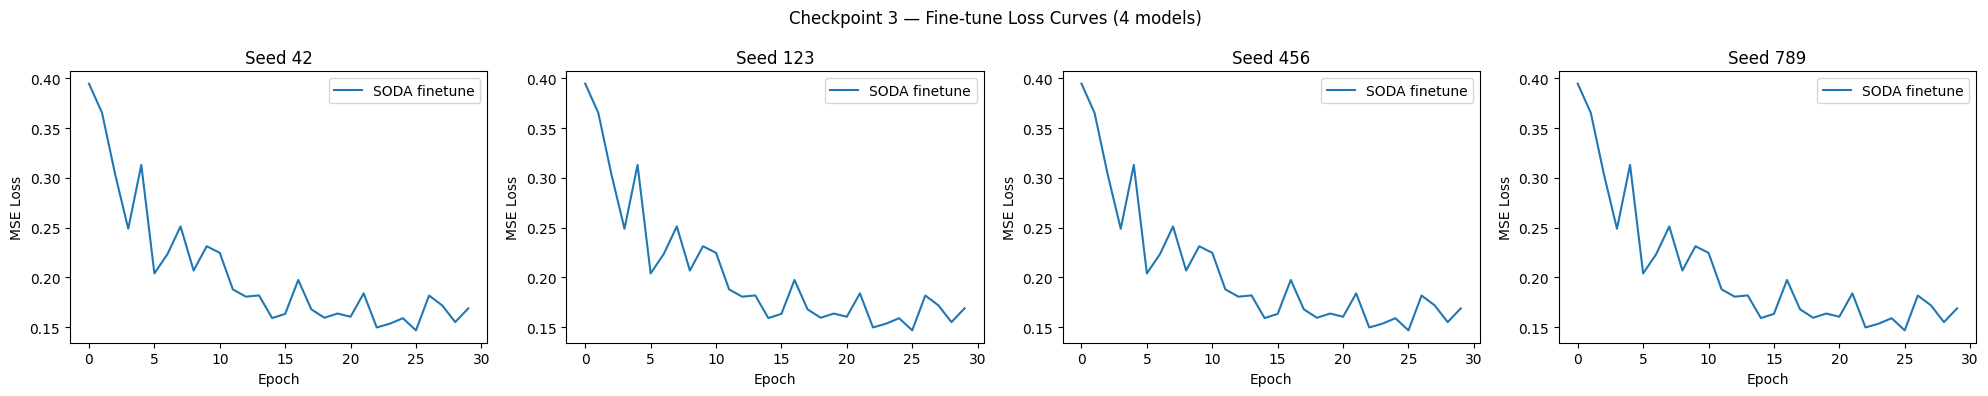

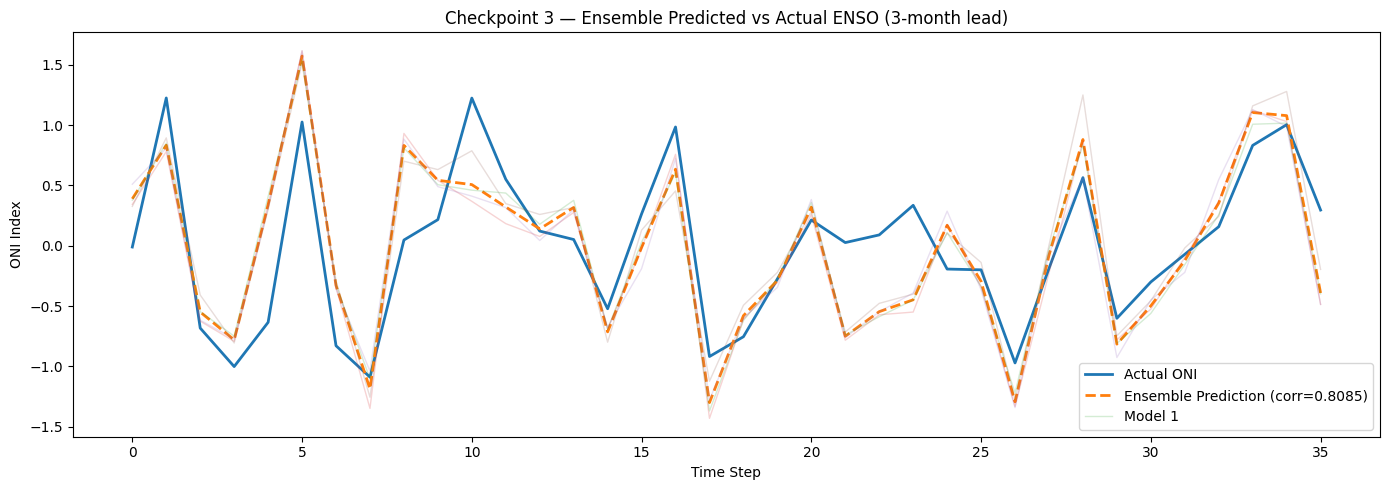


Individual model correlations:
  Model 1 (seed 42): 0.8014
  Model 2 (seed 123): 0.7917
  Model 3 (seed 456): 0.7895
  Model 4 (seed 789): 0.8291
Ensemble:                  0.8085


In [ ]:
# Loss curves for each model
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for idx, seed in enumerate(SEEDS):
    axes[idx].plot(tr_losses, label='SODA finetune')
    axes[idx].set_title(f'Seed {seed}')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('MSE Loss')
    axes[idx].legend()
plt.suptitle('Checkpoint 3 — Fine-tune Loss Curves (4 models)')
plt.tight_layout()
plt.savefig('/kaggle/working/checkpoint3_loss_curves.png')
plt.show()

# Ensemble prediction plot
plt.figure(figsize=(14, 5))
plt.plot(actuals,        label='Actual ONI', linewidth=2)
plt.plot(ensemble_preds, label=f'Ensemble Prediction (corr={corr:.4f})',
         linewidth=2, linestyle='--')
for i, preds in enumerate(all_preds):
    plt.plot(preds, alpha=0.2, linewidth=1,
             label=f'Model {i+1}' if i == 0 else None)
plt.xlabel('Time Step')
plt.ylabel('ONI Index')
plt.title('Checkpoint 3 — Ensemble Predicted vs Actual ENSO (3-month lead)')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/checkpoint3_predictions.png')
plt.show()

# Individual vs ensemble correlation
print("\nIndividual model correlations:")
for i, (preds, seed) in enumerate(zip(all_preds, SEEDS)):
    c, _ = pearsonr(preds, actuals)
    print(f"  Model {i+1} (seed {seed}): {c:.4f}")
print(f"Ensemble:                  {corr:.4f}")